In [4]:
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import smoothie
smoothie.suppress_warnings()

In [5]:
#read in raw data
adata = ad.read_h5ad("../data/mouse_E16.5_E1S1_raw_dnb.h5ad")
adata.shape

(175750455, 28204)

In [9]:
#filtering and log normalization

sc.pp.filter_cells(adata, min_counts=1)
sc.pp.filter_genes(adata, min_counts=100)
sc.pp.filter_genes(adata, min_cells=10)

sc.pp.log1p(adata)

print(adata.shape)


(175733183, 20203)


In [10]:
#smoothing

target_microns = 20.0
micron_to_unit_conversion = 2
sm_adata = smoothie.run_parallelized_smoothing(
    adata,
    grid_based_or_not=True,
    gaussian_sd=target_microns * micron_to_unit_conversion,
    min_spots_under_gaussian=25
)

#save smoothed data to data folder
sm_adata.write_h5ad("../data/mouse_E16.5_E1S1_smooth.h5ad")

Checking dataset point density...
Fitting grid to tissue coordinates...
Variation in X-direction: 25549
Variation in Y-direction: 17467
Number of points in fitted grid: 218394
Gaussian smoothing will run in 36 chunks.
Smoothing chunk: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 
Total runtime for grid-based Gaussian smoothing: 670.69 seconds.



In [13]:
#compute correlation matrix

pearsonR_mat, pval_mat = smoothie.compute_correlation_matrix(sm_adata.X)

#save matrices to data folder
np.save(f"../data/mouse_E16.5_E1S1_pearsonR.npy", pearsonR_mat)
np.save(f"../data/mouse_E16.5_E1S1_pval.npy", pval_mat)
np.save(f"../data/mouse_E16.5_E1S1_gene_names.npy", sm_adata.var_names.to_numpy())


compute_correlation_matrix running...
Total runtime for compute_correlation_matrix: 891.31 seconds.



Running network clustering with parameters:
PCC hard cutoff: 0.3, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.4, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.5, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.6, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.7, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.8, clustering soft power: 1, 3, 5, 7, 9, 


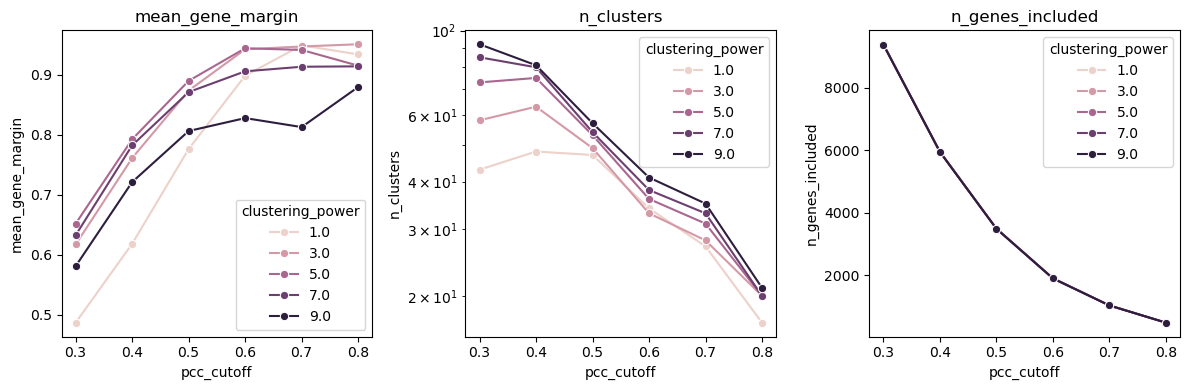

In [14]:
#create graphs to determine clustering parameters

smoothie.select_clustering_params(
    gene_names=sm_adata.var_names,
    pearsonR_mat=pearsonR_mat,
    output_folder=None,
    pcc_cutoffs=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    clustering_powers=[1, 3, 5, 7, 9],
    min_genes_for_module=5
)

In [15]:
#construct network and save to Cytoscape folder

edge_list, node_label_df = smoothie.make_spatial_network(
    pearsonR_mat=pearsonR_mat, # don't change
    gene_names=sm_adata.var_names, # don't change
    pcc_cutoff=0.4,
    clustering_power=3,
    output_folder='../Cytoscape'
)

# Filter node_label_df for only genes within modules of size 2 or more.
modules_df = node_label_df.groupby('module_label').filter(lambda x: len(x) >= 2)

# Examine modules
modules_df

,name,module_label,degree,weighted_degree,rescaled_weighted_degree,clustering_coeff,margin_score
0,Tuba1a,1,1478,812.890845,74.143671,0.247307,0.804284
1,Rtn1,1,1372,755.933573,67.055153,0.270660,0.920902
2,Crmp1,1,1316,718.583794,60.133281,0.295463,0.941861
3,Tubb2b,1,1426,768.800286,59.681139,0.264329,0.887789
4,Basp1,1,1432,775.623714,59.115128,0.259510,0.890897
...,...,...,...,...,...,...,...
5940,Lsr,265,1,0.551677,0.016155,0.000000,1.000000
5941,Pxmp2,266,1,0.425356,0.000075,0.000000,1.000000
5942,Gm15788,266,1,0.425356,0.000075,0.000000,1.000000
5943,Uqcr10,267,127,57.200867,0.446982,0.843895,0.995271


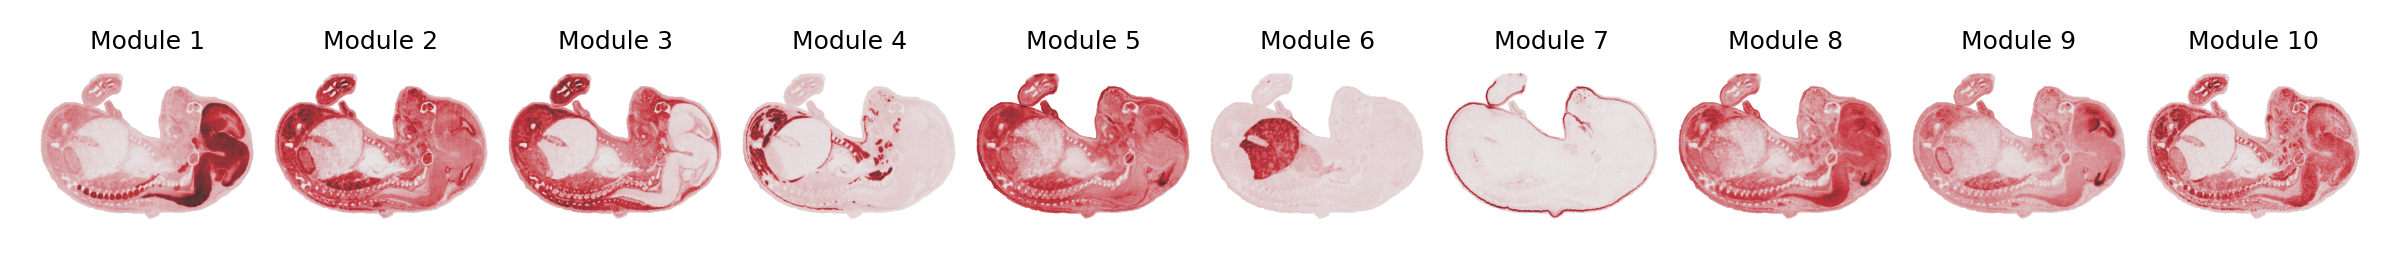

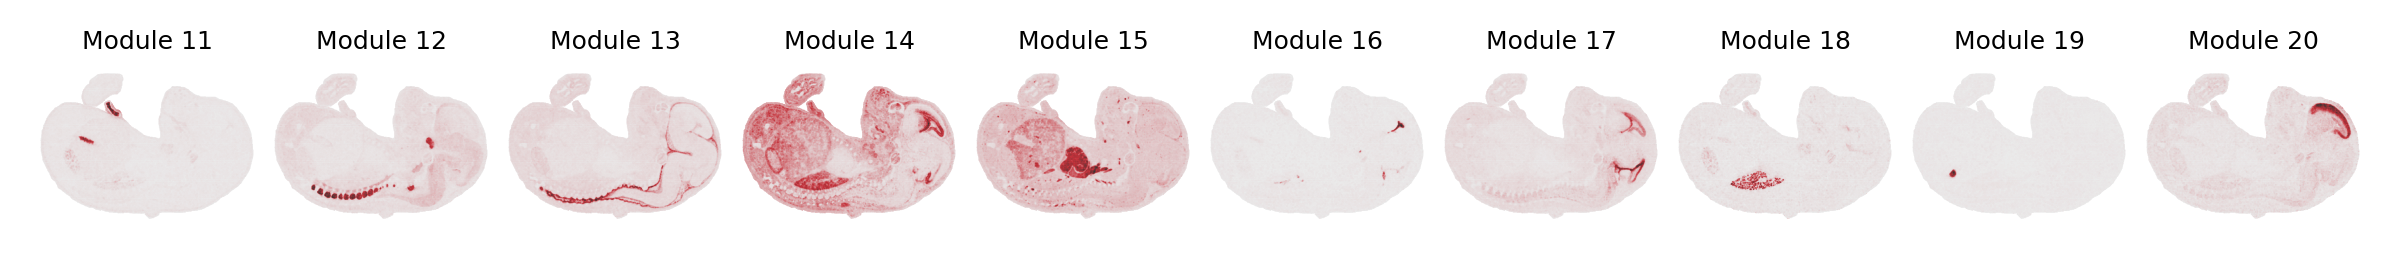

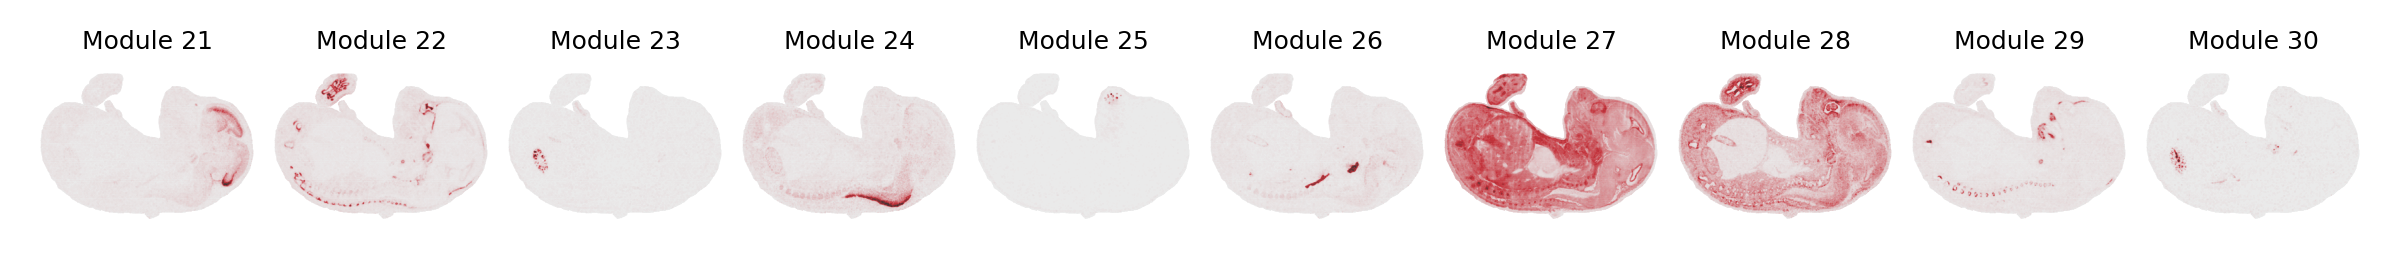

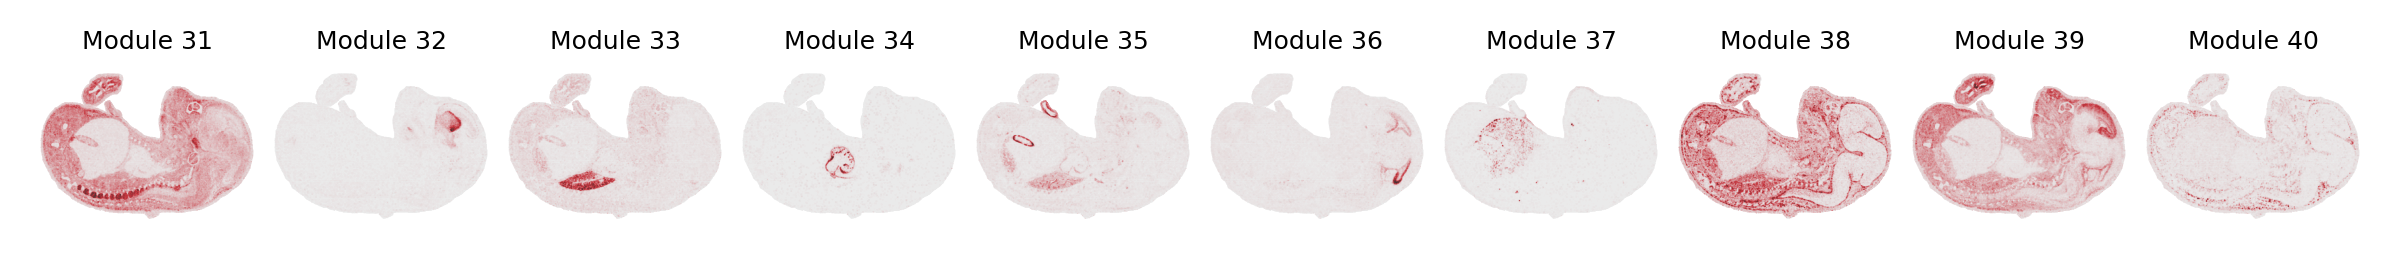

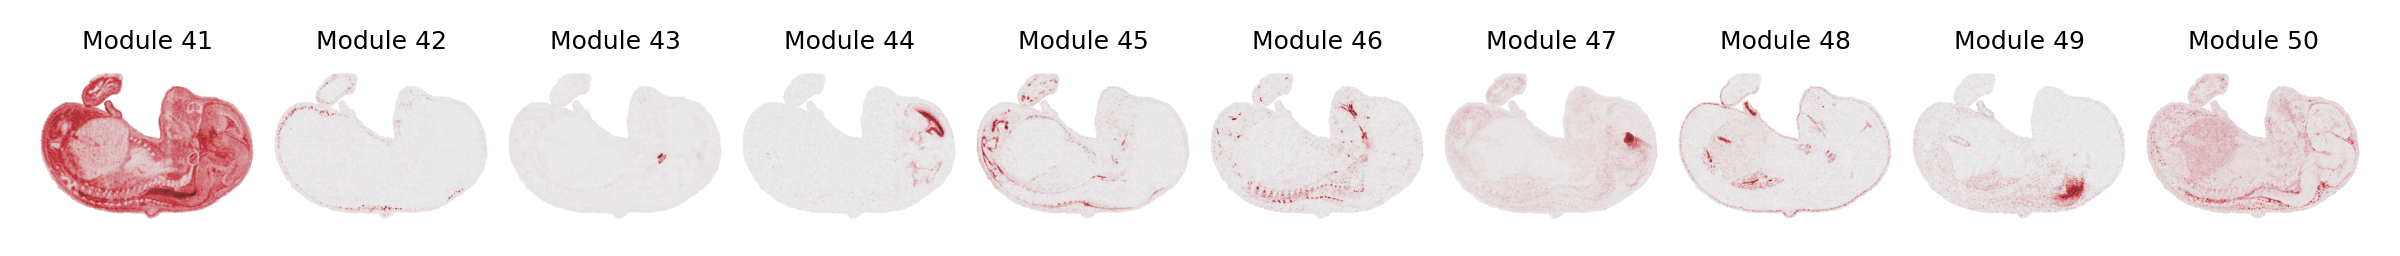

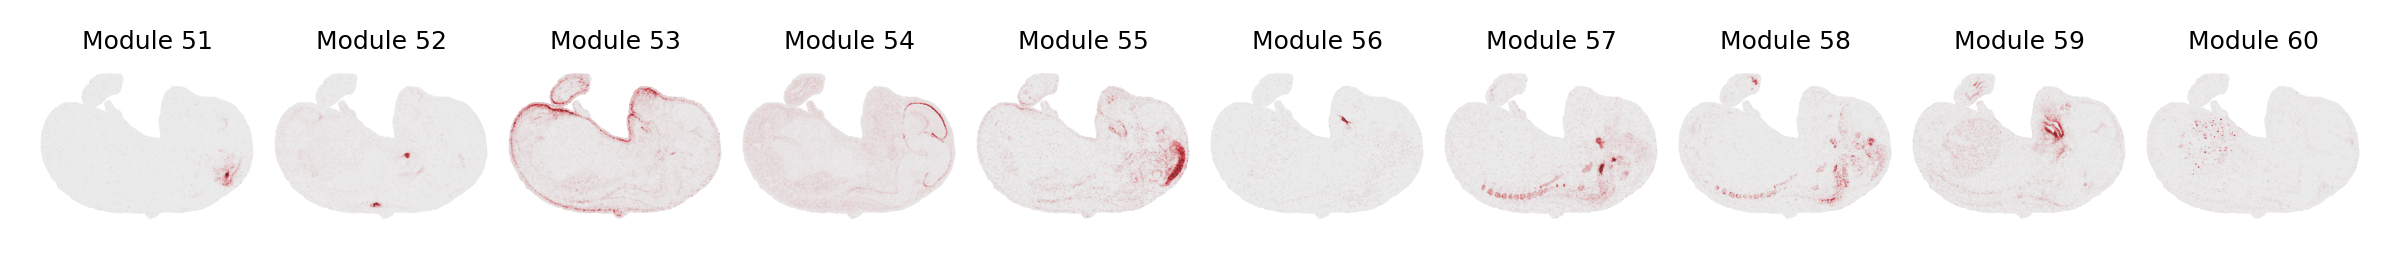

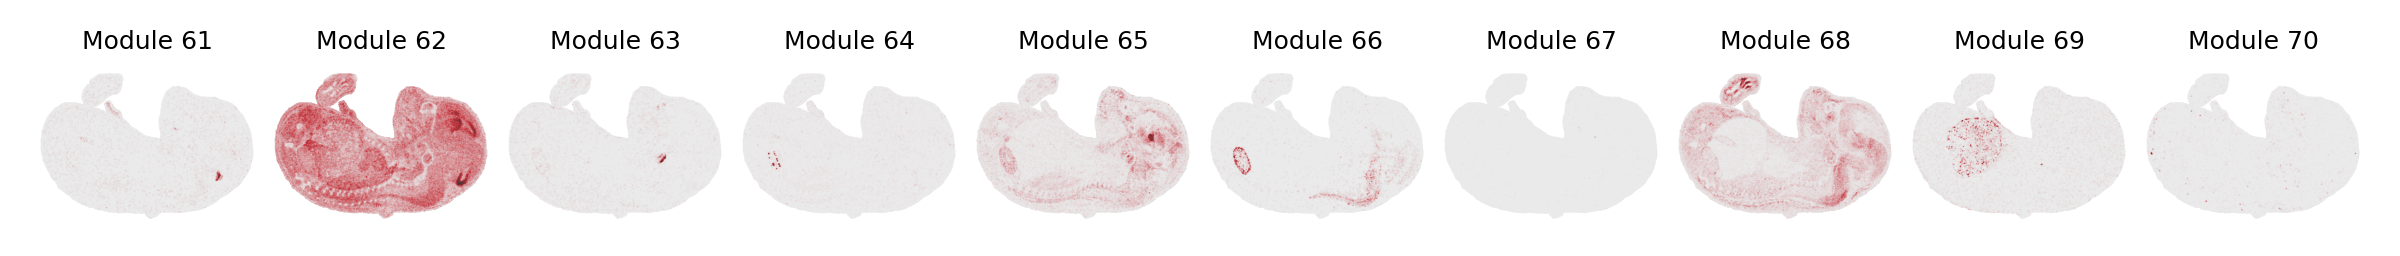

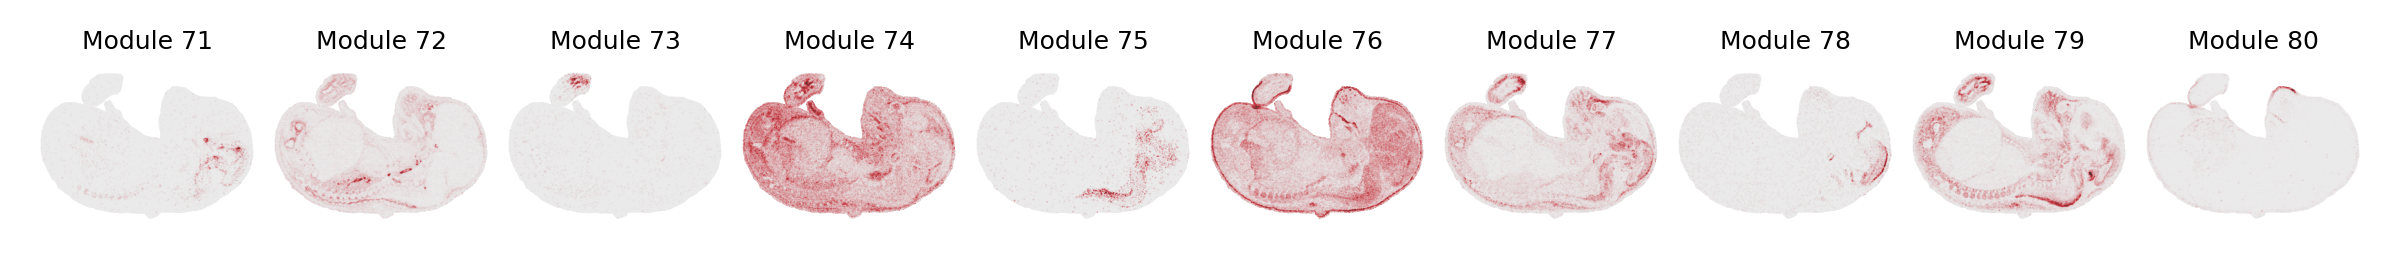

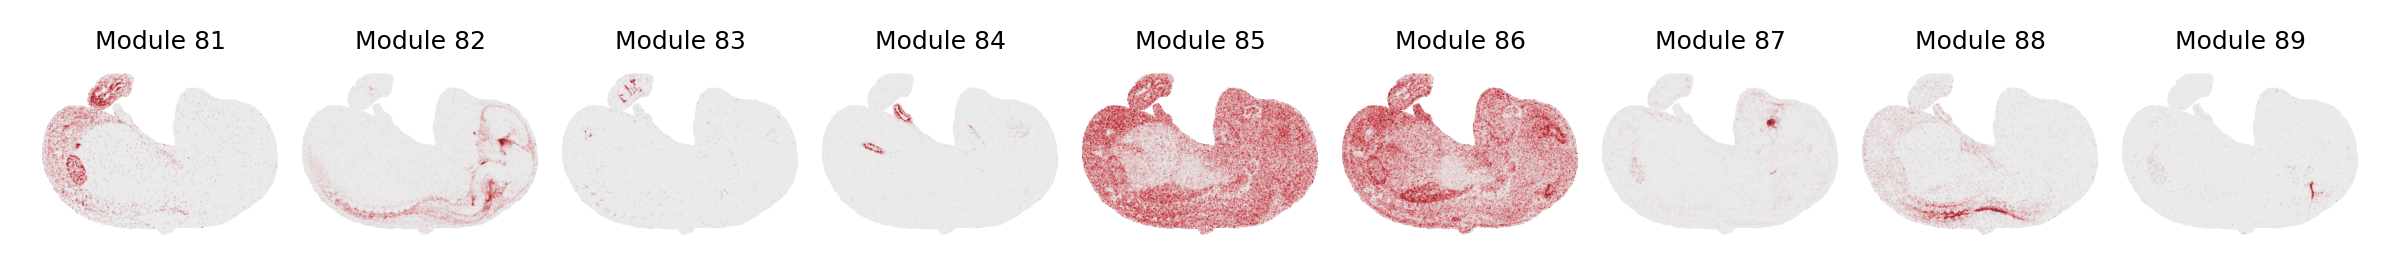

In [17]:
#plot the gene modules

smoothie.plot_modules(
    sm_adata,
    node_label_df,
    output_folder='./module_plots',
    min_genes=3, # Minimum number of genes in a module to plot the module
    spot_size=50, # Adjust for optimal visualization
    plots_per_row=10,
    dpi=150 # low resolution here for github, better to choose 300-600!
)